In [98]:
import pandas as pd
import sys
sys.path.insert(0, "../")
from utils.ploting_figures import MakePlots
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [99]:
df=pd.read_csv("RandomForest_Grid_42_metrics.csv")

In [100]:
df

,dataset,model,sampling,acc,recall,precision,f1,mcc,roc_auc,conf_matrix
0,Train,Random_Forest,Original,0.728571,0.728571,0.726253,0.723117,0.540596,0.902225,"{0: {0: 458, 1: 125, 2: 35}, 1: {0: 66, 1: 202..."
1,Validation,Random_Forest,Original,0.387833,0.387833,0.360282,0.370746,-0.069339,0.442933,"{0: {0: 82, 1: 58, 2: 21}, 1: {0: 47, 1: 14, 2..."
2,Train,Random_Forest,Under,0.842105,0.842105,0.843044,0.842361,0.763330,0.975057,"{0: {0: 128, 1: 17, 2: 8}, 1: {0: 17, 1: 134, ..."
3,Validation,Random_Forest,Under,0.361345,0.361345,0.359860,0.357526,0.040036,0.553497,"{0: {0: 18, 1: 15, 2: 14}, 1: {0: 11, 1: 10, 2..."
4,Train,Random_Forest,Over,0.818685,0.818685,0.816842,0.817182,0.728410,0.962243,"{0: {0: 429, 1: 102, 2: 16}, 1: {0: 83, 1: 391..."
5,Validation,Random_Forest,Over,0.597052,0.597052,0.587032,0.589480,0.398437,0.705426,"{0: {0: 71, 1: 53, 2: 10}, 1: {0: 48, 1: 65, 2..."


In [101]:
conf_matrix = df[["dataset", "sampling", "conf_matrix"]]
conf_matrix

,dataset,sampling,conf_matrix
0,Train,Original,"{0: {0: 458, 1: 125, 2: 35}, 1: {0: 66, 1: 202..."
1,Validation,Original,"{0: {0: 82, 1: 58, 2: 21}, 1: {0: 47, 1: 14, 2..."
2,Train,Under,"{0: {0: 128, 1: 17, 2: 8}, 1: {0: 17, 1: 134, ..."
3,Validation,Under,"{0: {0: 18, 1: 15, 2: 14}, 1: {0: 11, 1: 10, 2..."
4,Train,Over,"{0: {0: 429, 1: 102, 2: 16}, 1: {0: 83, 1: 391..."
5,Validation,Over,"{0: {0: 71, 1: 53, 2: 10}, 1: {0: 48, 1: 65, 2..."


In [102]:
import ast

# Si las matrices están como strings, conviértelas a dicts
df["conf_matrix"] = df["conf_matrix"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)


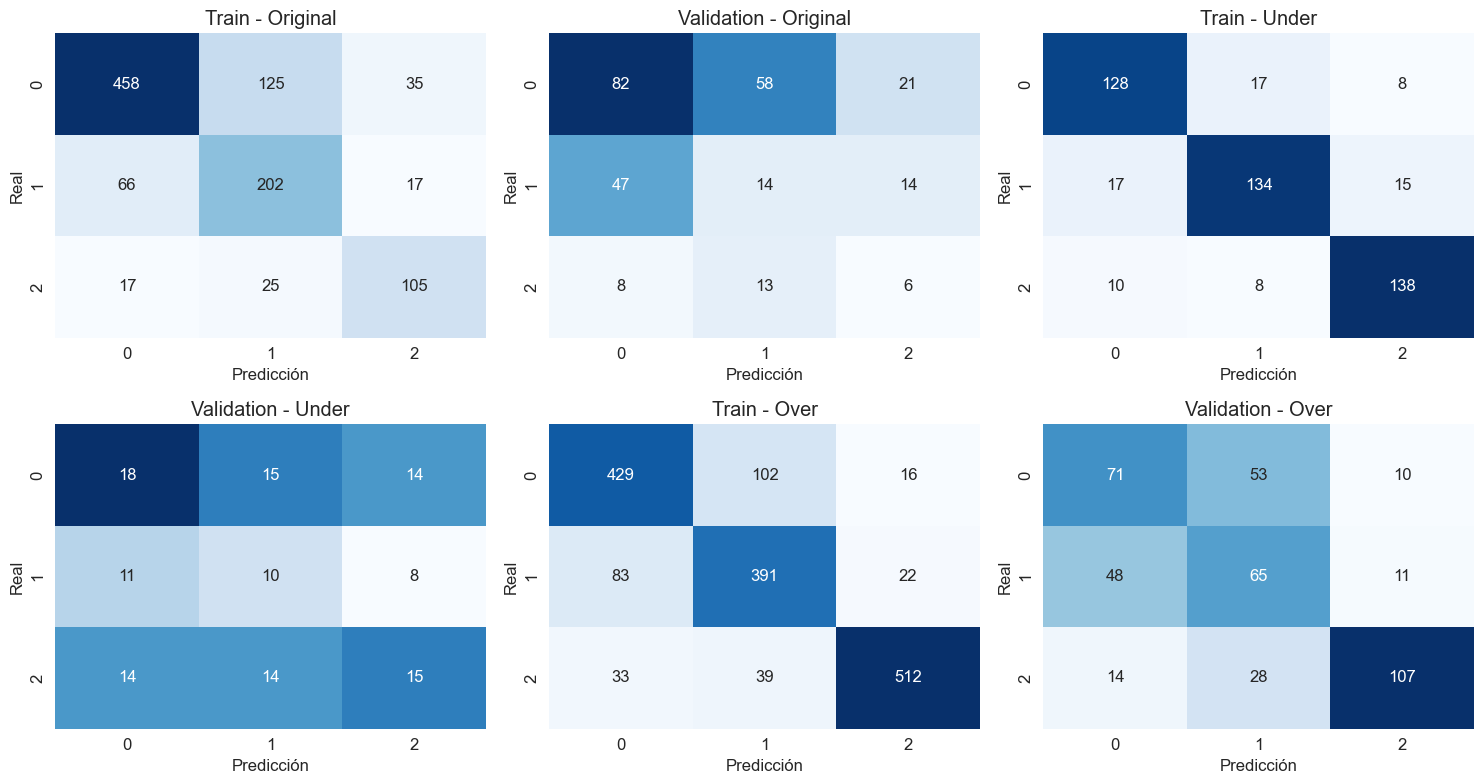

In [103]:
def dict_to_df(conf_dict):
    df_conf = pd.DataFrame(conf_dict).T  # Transponer para que filas = reales y columnas = predichos
    return df_conf.fillna(0).astype(int)

# Parámetros de la figura
n_rows = df.shape[0]
n_cols = 3
n_filas = int(np.ceil(n_rows / n_cols))

fig, axes = plt.subplots(n_filas, n_cols, figsize=(n_cols * 5, n_filas * 4))
axes = axes.flatten()

for idx, row in df.iterrows():
    conf_dict = row["conf_matrix"]
    cm_df = dict_to_df(conf_dict)

    ax = axes[idx]
    sns.heatmap(cm_df, annot=True, fmt='d', cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{row['dataset']} - {row['sampling']}")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

# Oculta los subplots vacíos
for i in range(idx + 1, len(axes)):
    axes[i].axis("off")

plt.tight_layout()

In [104]:
df.drop(columns=["conf_matrix"], inplace=True)

In [105]:
df.rename(columns={
    "acc": "Accuracy",
    "recall": "Recall",
    "precision": "Precision",
    "f1": "F1-score",
    "mcc": "MCC",
    "roc_auc": "ROC-AUC",
    "model": "Algorithm",
    "dataset": "Stage",
}, inplace=True)

In [106]:
df

,Stage,Algorithm,sampling,Accuracy,Recall,Precision,F1-score,MCC,ROC-AUC
0,Train,Random_Forest,Original,0.728571,0.728571,0.726253,0.723117,0.540596,0.902225
1,Validation,Random_Forest,Original,0.387833,0.387833,0.360282,0.370746,-0.069339,0.442933
2,Train,Random_Forest,Under,0.842105,0.842105,0.843044,0.842361,0.763330,0.975057
3,Validation,Random_Forest,Under,0.361345,0.361345,0.359860,0.357526,0.040036,0.553497
4,Train,Random_Forest,Over,0.818685,0.818685,0.816842,0.817182,0.728410,0.962243
5,Validation,Random_Forest,Over,0.597052,0.597052,0.587032,0.589480,0.398437,0.705426


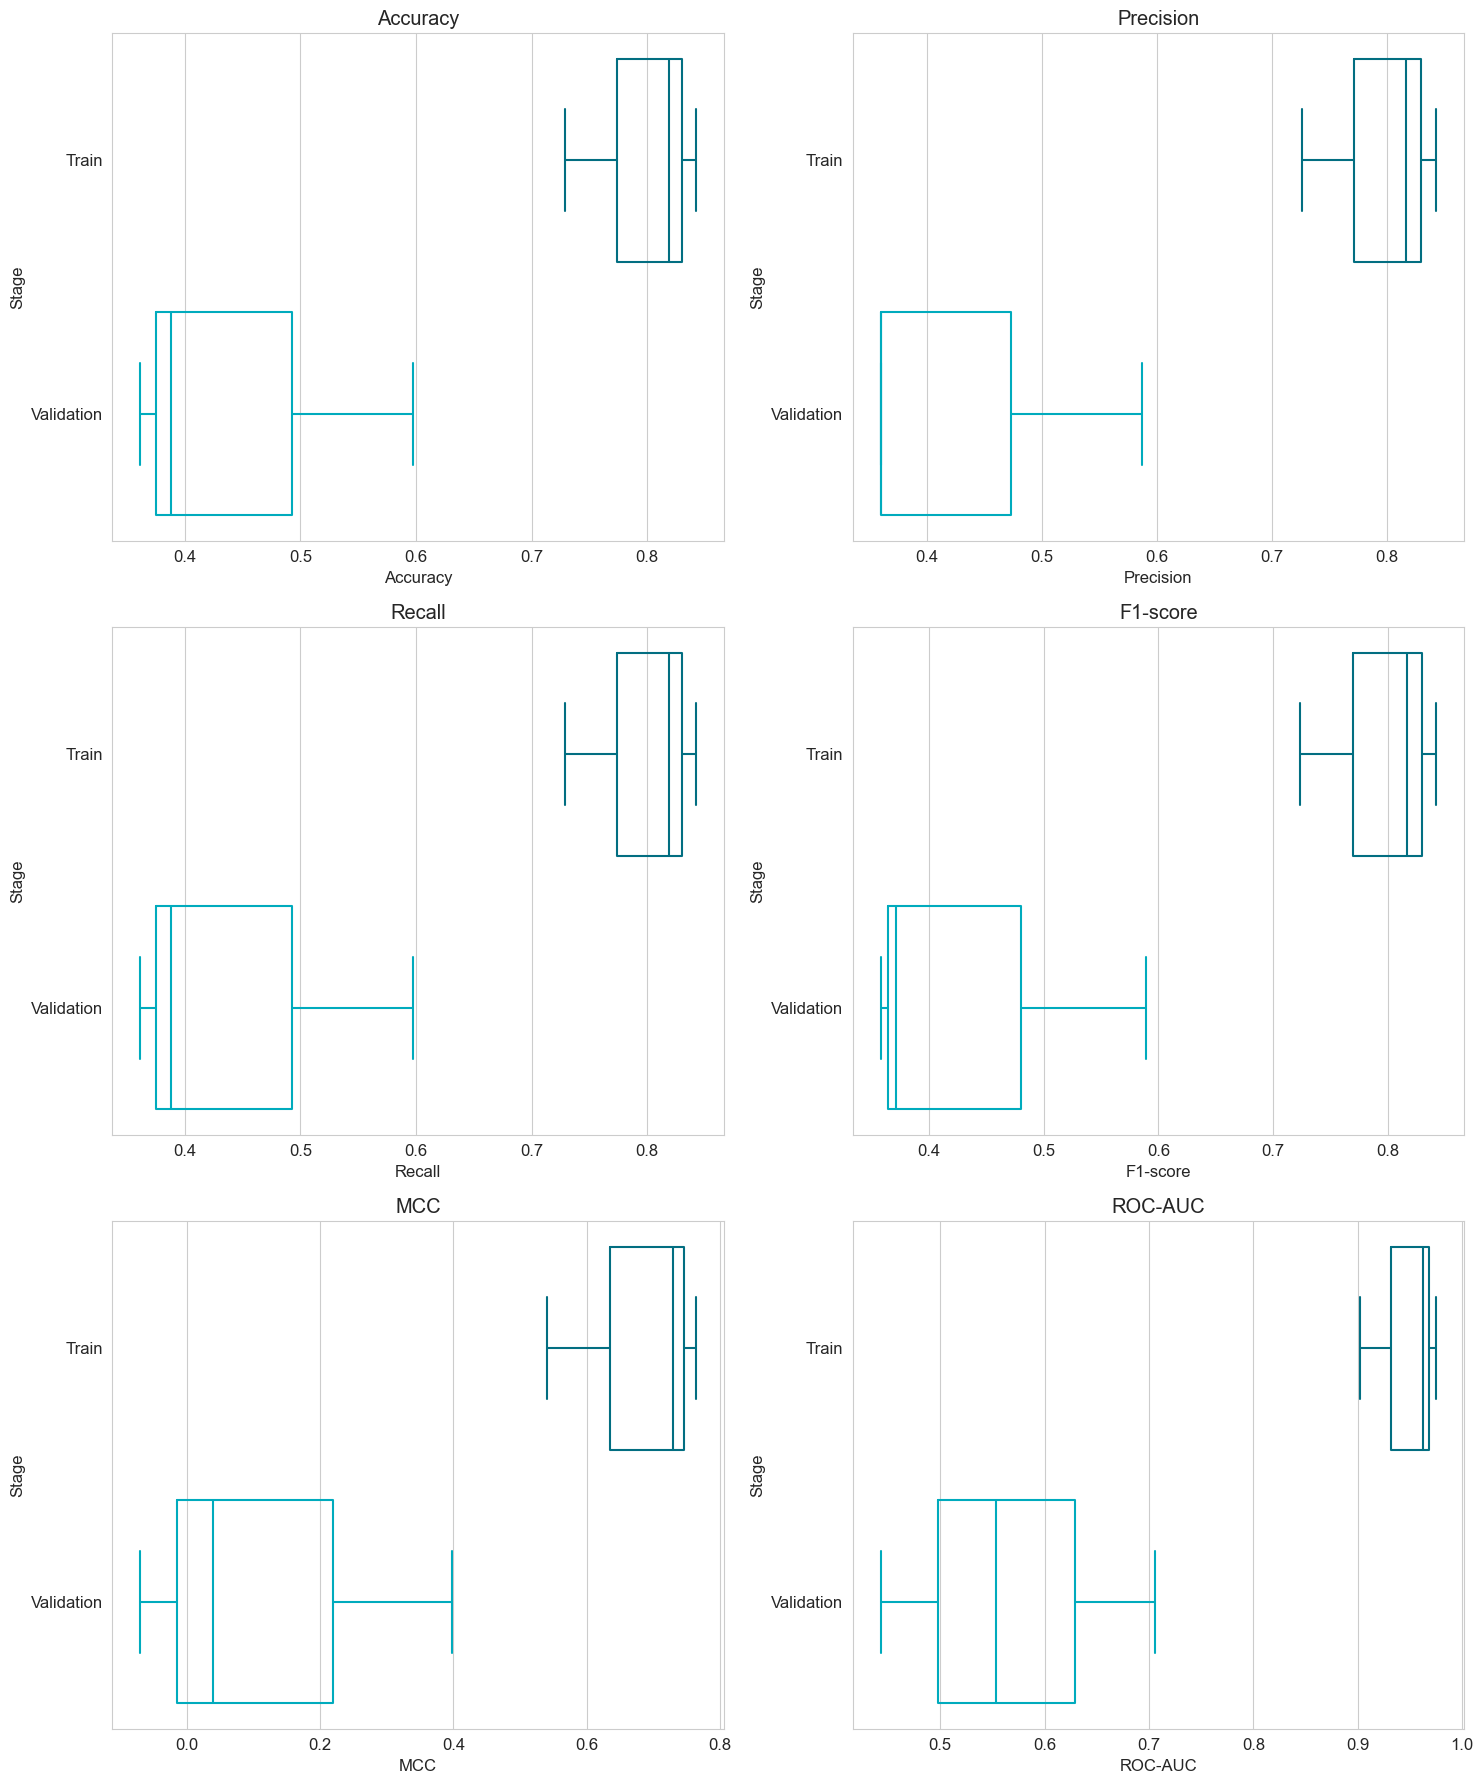

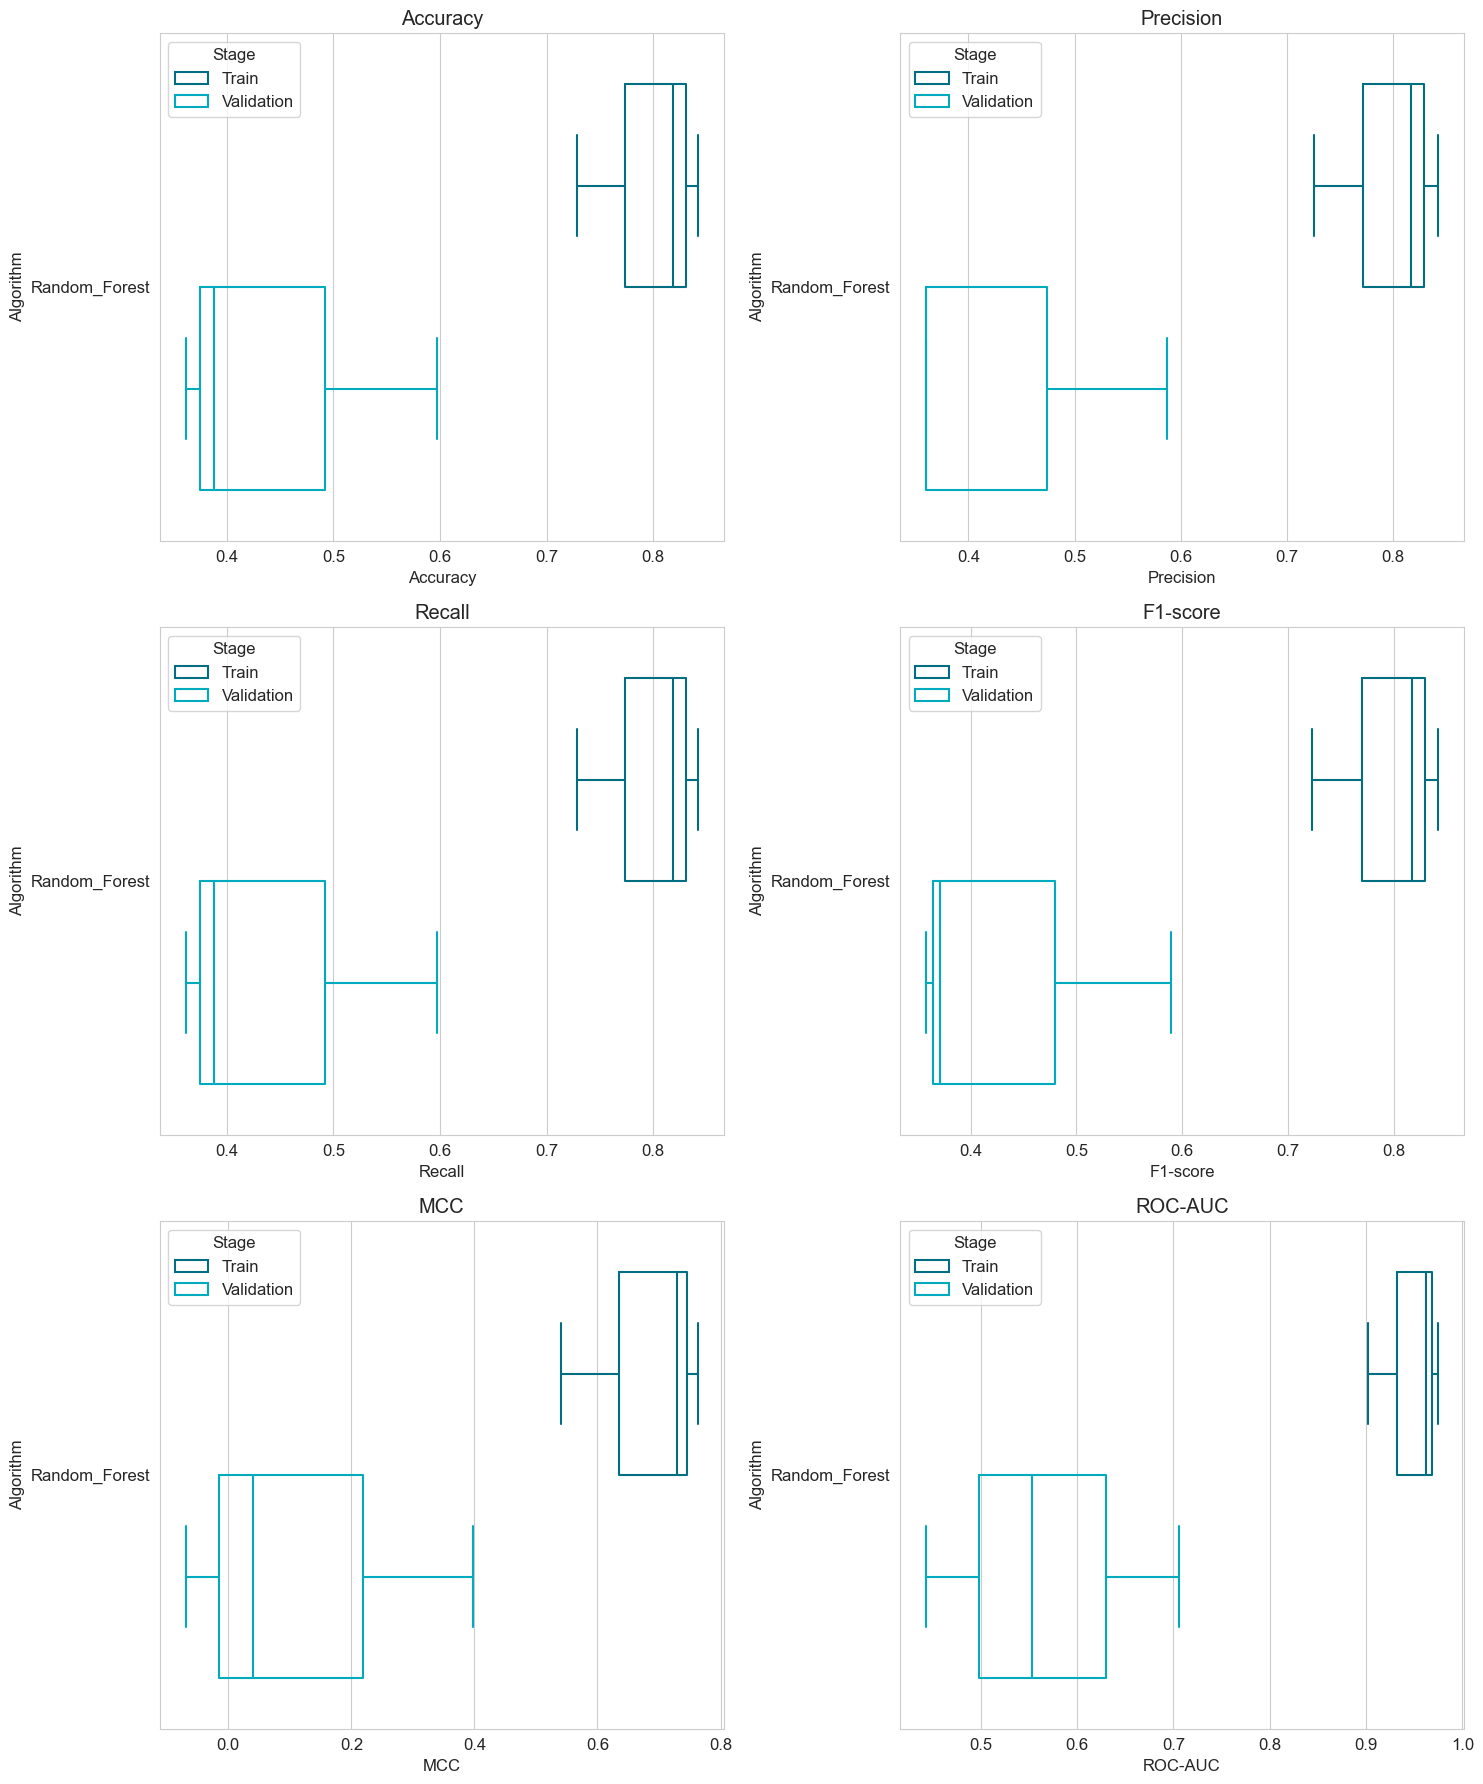

In [107]:
make_plots = MakePlots(dataset=df, path_export="../img/", hue="Stage", sample="Base", )
make_plots.plot_by_stage()
make_plots.plot_by_algorithm()

In [108]:
palette_values = ['#026E81', '#00ABBD', '#FFB255', '#F45F74']
palette_values2=['#00ABBD', '#FFB255', '#F45F74']
colors = sns.color_palette(palette_values)
colors2 = sns.color_palette(palette_values2)

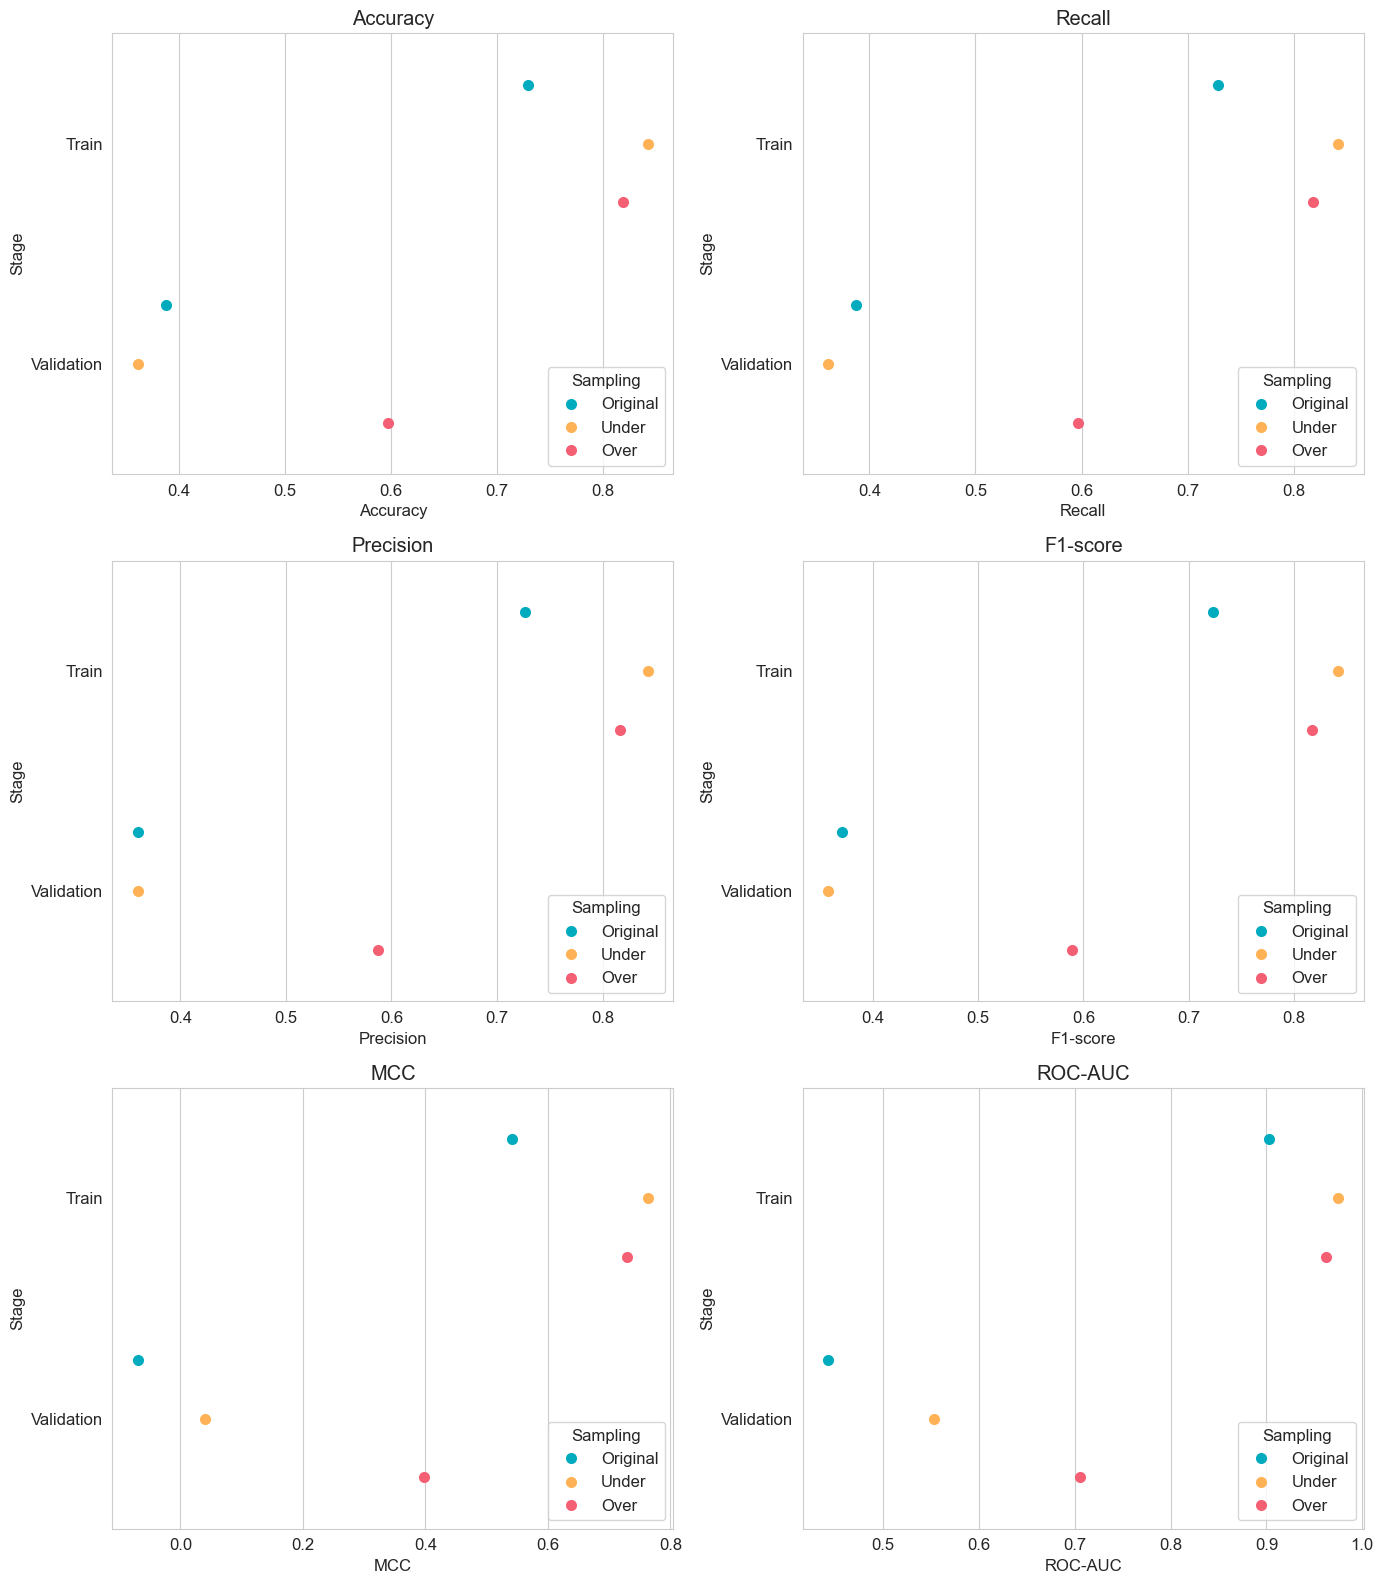

In [109]:
# Lista de métricas que quieres graficar
metrics = ["Accuracy", "Recall", "Precision", "F1-score", "MCC", "ROC-AUC"]

# Graficar
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.stripplot(
        data=df,
        x=metric,
        y="Stage",
        hue="sampling",
        palette=colors2,
        dodge=True,
        jitter=0.25,
        size=8,
        ax=ax
    )
    ax.set_title(metric)
    ax.legend(title="Sampling", loc="lower right")

plt.tight_layout()
plt.show()

In [110]:
df2=pd.read_csv("RandomForest_Regression_Grid_42_grid_metrics.csv")

In [111]:
df2

,dataset,model,sampling,MAE,MSE,RMSE,R2
0,Train,Random_Forest_Regressor,Original,923.063143,1.175504e+06,1084.206577,0.488184
1,Validation,Random_Forest_Regressor,Original,1769.625794,3.683174e+06,1919.159790,-0.618835


In [112]:
metrics = ["MAE", "MSE", "RMSE", "R2"]

In [113]:
df2.drop(columns=df2[["model", "sampling"]], inplace=True)

In [114]:
df_melt = df2.melt(
    id_vars=["dataset"], 
    value_vars=metrics,
    var_name="Metric", 
    value_name="Score"
)

In [115]:
metrics_unique = df_melt['Metric'].unique()

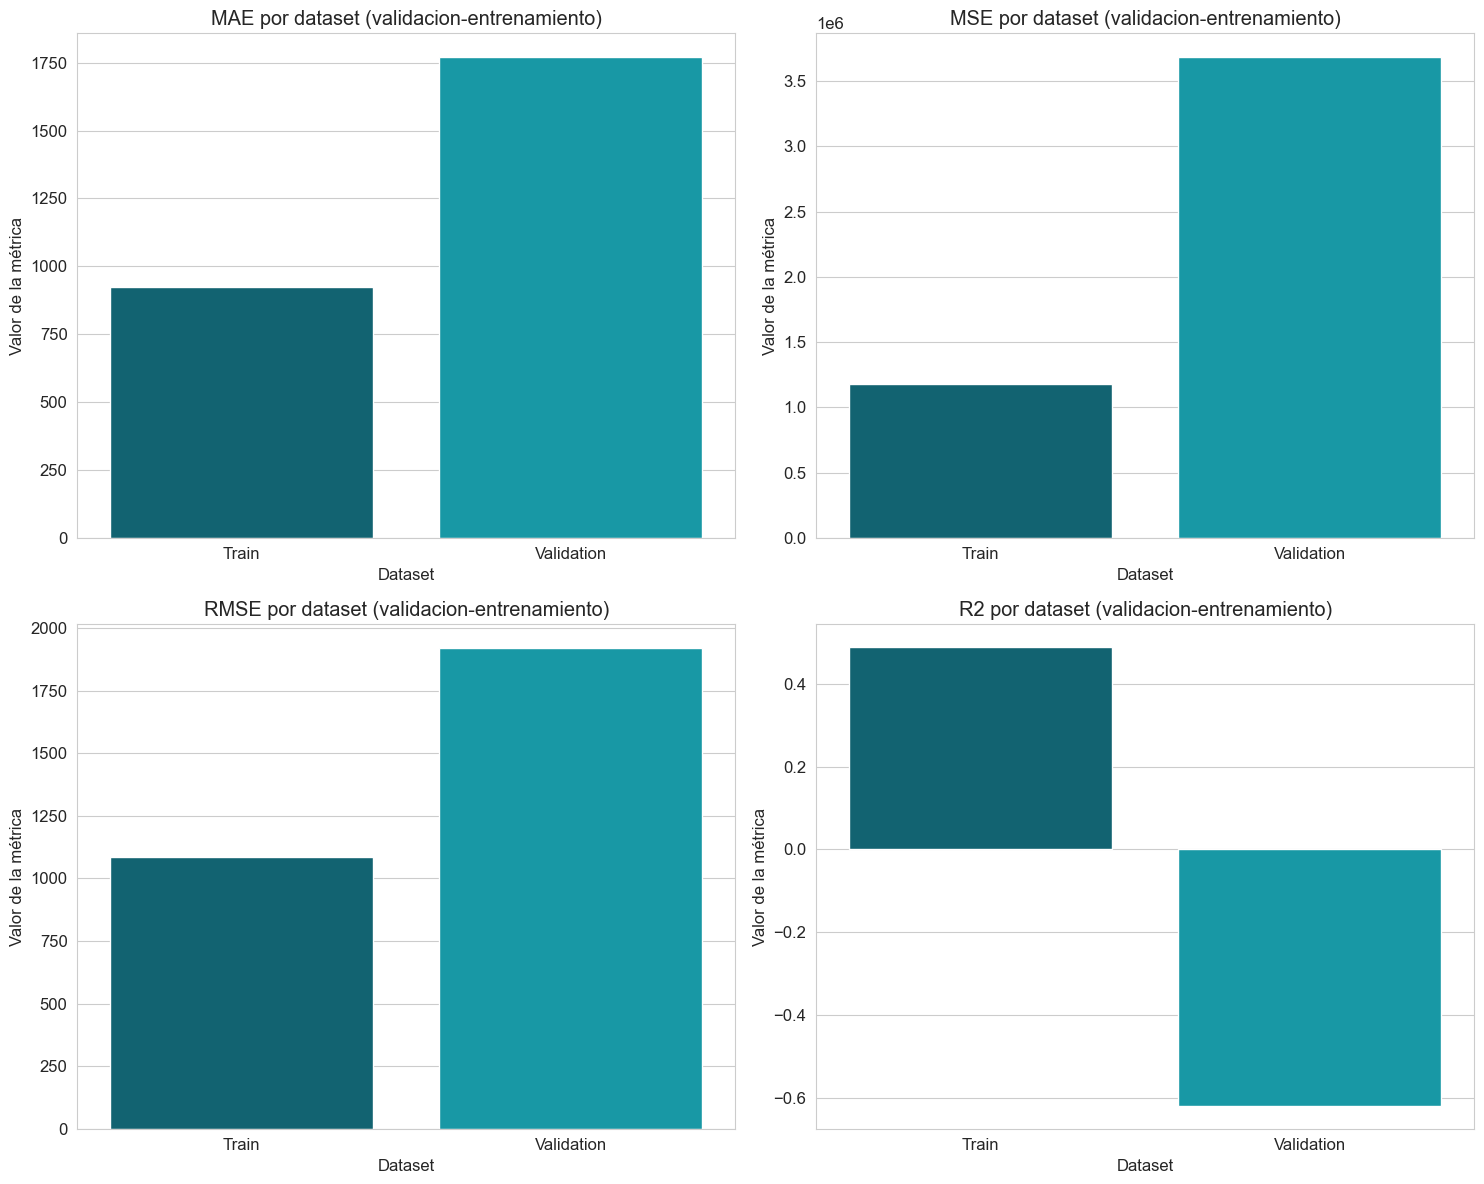

In [116]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_unique):
    df_metric = df_melt[df_melt['Metric'] == metric]
    sns.barplot(data=df_metric, x='dataset', y='Score', palette=colors, ax=ax)
    ax.set_title(f"{metric} por dataset (validacion-entrenamiento)")
    ax.set_ylabel("Valor de la métrica")
    ax.set_xlabel("Dataset")

plt.tight_layout()
plt.savefig("../img/RandomForest_Regression_all_metrics.png")
plt.show()